In [2]:
#%pip install pandas numpy seaborn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import time
import datetime

#%pip install prefixspan
from prefixspan import PrefixSpan

# Задание 1. Реализация AprioriAll
## Реализовать алгоритм AprioriAll с нуля на Python.
## Функционал:
- Загрузка данных из CSV (поля: client_id, date, items).
- Преобразование в последовательности клиентов (сортировка по дате, группировка товаров внутри транзакции).
- Генерация кандидатов и подсчёт поддержки по клиентам.
- Поиск всех частых последовательностей.
### Проверка: на синтетическом примере (можно взять пример из лекции с 3–4 клиентами) результат должен совпадать с ручным расчётом.

In [ ]:
def is_subsequence(candidate, customer_sequence):
    it = iter(customer_sequence)

    return all(set(cand_set).issubset(seq_set) for cand_set in candidate for seq_set in it)

def AprioriAll(data_sequences, min_support_pct):
    n_support = min_support_pct * len(data_sequences)
    
    item_counts = {}
    for seq in data_sequences:
        unique_items = set().union(*seq)
        for item in unique_items:
            item_counts[item] = item_counts.get(item, 0) + 1
            
    current_frequent = {((item,),): cnt for item, cnt in item_counts.items() if cnt >= n_support}
    all_frequent_sequences = dict(current_frequent)
    
    k = 2
    while current_frequent:
        items_list = list(current_frequent.keys())
        candidates = set()
        
        for i in range(len(items_list)):
            for j in range(len(items_list)):
                seq1, seq2 = items_list[i], items_list[j]
                if seq1[1:] == seq2[:-1]:
                    new_cand = seq1 + (seq2[-1],)
                    candidates.add(new_cand)
        
        next_frequent = {}
        for cand in candidates:
            cnt = sum(1 for seq in data_sequences if is_subsequence(cand, seq))
            if cnt >= n_support:
                next_frequent[cand] = cnt
            
        all_frequent_sequences.update(next_frequent)
        current_frequent = next_frequent
        k += 1
        
    return all_frequent_sequences



In [113]:
data_syn = {
    "customer_1": [frozenset([1,5]), frozenset([2]), frozenset([3]), frozenset([4])],
    "customer_2": [frozenset([1]), frozenset([3]), frozenset([4]), frozenset([3,5])],
    "customer_3": [frozenset([1]), frozenset([2]), frozenset([3]), frozenset([4])],
    "customer_4": [frozenset([1]), frozenset([3]), frozenset([5]), frozenset([4])],
    "customer_5": [frozenset([4]), frozenset([5])]
}

seq_syn = AprioriAll(data_syn, 0.4)

for item, cnt in seq_syn.items():
  print(f"{item}: {cnt}")

((1,),): 4
((2,),): 2
((3,),): 4
((4,),): 5
((5,),): 4
((3,), (4,)): 4
((1,), (2,)): 2
((5,), (4,)): 2
((1,), (3,)): 4
((1,), (4,)): 4
((3,), (5,)): 2
((2,), (3,)): 2
((1,), (5,)): 2
((2,), (4,)): 2
((4,), (5,)): 2
((1,), (2,), (3,)): 2
((1,), (3,), (4,)): 4
((2,), (3,), (4,)): 2
((1,), (2,), (4,)): 2
((1,), (3,), (5,)): 2
((1,), (2,), (3,), (4,)): 2


# Задание 2. Анализ реальных данных
## На датасете Online Retail (https://www.kaggle.com/datasets/lakshmi25npathi/onlineretail-dataset/data или аналогичном) выполнить:
### 1. Влияние минимальной поддержки
Запустить AprioriAll при min_sup = 5%, 10%, 20%.
Построить график: количество найденных частых последовательностей vs min_sup.
Сделать вывод о масштабируемости.
### 2. Сравнение с ассоциативными правилами
- Применить классический Apriori (без учёта последовательности и ID клиента).
- Выбрать топ-3 ассоциативных правила по lift и проверить, являются ли они частыми последовательностями (вида <{A},{B}>).
- Объяснить расхождения.
### 3. Временные окна
- Добавить параметр max_gap (максимальный допустимый разрыв между транзакциями одного клиента, например 7 дней).
- Сравнить набор частых последовательностей с max_gap = ∞ и max_gap = 7.
- Привести пример шаблона, который исчезает или появляется.
### 4. Визуализация
- Выбрать один наиболее интересный частый шаблон длины ≥ 2.
- Построить направленный граф перехода товаров.
- Кратко интерпретировать (бизнес-гипотеза).

In [ ]:
# %pip install openpyxl

df = pd.read_excel("online_retail_II.xlsx")
print(df.head(5))
print(f"Исходный размер: {df.shape}")
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df['Customer ID'] = df['Customer ID'].astype(int)

# В tech_codes находятся коды технических операций, которые нас не интересуют (брак, оплата доставки, тестовые покупки и т.д.)
tech_codes = ['ADJUST', 'POST', 'C2', 'M', 'TEST001', 'TEST002']
df['StockCode'] = df['StockCode'].astype(str)
df = df[~df['StockCode'].isin(tech_codes)]
print(f"После очистки: {df.shape}")
print("Уникальных товаров: ", len(df['StockCode'].unique()))
print("Транзакций: ", len(df['Invoice'].unique()))
print("Покупателей: ", len(df['Customer ID'].unique()))

df = df.sort_values(['Customer ID', 'InvoiceDate'])
customer_groups = df.groupby('Customer ID')
data = dict()

for cid, group in customer_groups:
  sequences = group.groupby('InvoiceDate')['StockCode'].apply(set).tolist()
  data[cid] = sequences

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Исходный размер: (525461, 8)
После очистки: (406367, 8)
Уникальных товаров:  4011
Транзакций:  18994
Покупателей:  4285


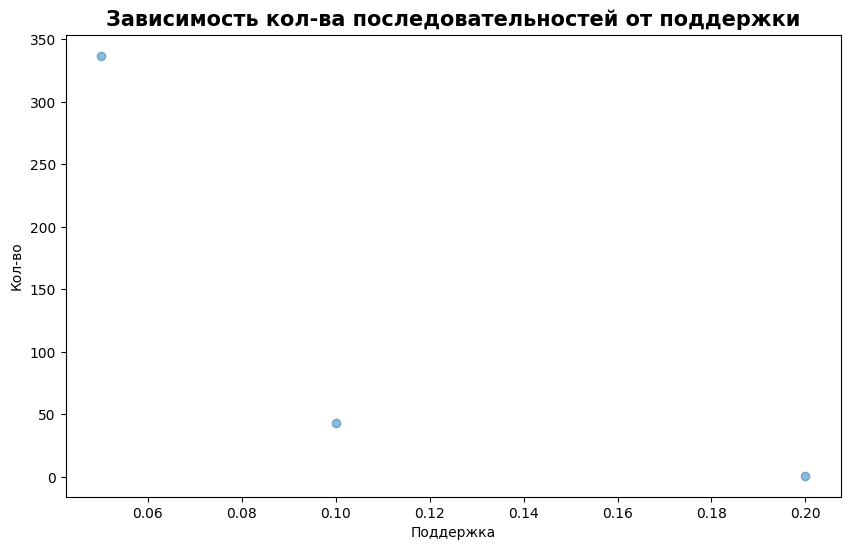

In [27]:
min_supports = [0.05, 0.1, 0.2]
n = len(data)
seq_len = []

data_test = AprioriAll(data, min_supports[0])
seq_len.append(len(data_test))
sequences_01 = {k: v for k, v in data_test.items() if v > n * min_supports[1]}
seq_len.append(len(sequences_01))
sequences_02 = {k: v for k, v in sequences_01.items() if v > n * min_supports[2]}
seq_len.append(len(sequences_02))

plt.figure(figsize=(10, 6))
plt.title("Зависимость кол-ва последовательностей от поддержки", fontsize=15, fontweight='bold')
plt.xlabel("Поддержка")
plt.ylabel("Кол-во")
plt.scatter(min_supports, seq_len, alpha=0.5)
plt.show()

In [39]:
for i in range(3):
  print(f"{min_supports[i]}: {seq_len[i]}")

0.05: 337
0.1: 43
0.2: 1


In [ ]:
def is_subsequence(candidate, customer_seq):
    it = iter(customer_seq)
    for item in candidate:
        found = False
        for transaction_set in it:
            if item in transaction_set:
                found = True
                break
        if not found:
            return False
    return True

def Apriori(transactions, min_support):
    n = len(transactions)
    n_support = min_support * n
    
    item_counts = {}
    for customer_id, seq in transactions.items():
        unique_items = set().union(*seq)
        for item in unique_items:
            item_counts[(item,)] = item_counts.get((item,), 0) + 1
            
    current_candidates = {k: v / n for k, v in item_counts.items() if v >= n_support}
    supported_products = {}

    while current_candidates:
        supported_products.update(current_candidates)
        future_candidates = {}
        
        items_list = list(current_candidates.keys())
        
        for i in range(len(items_list)):
            for j in range(len(items_list)):
                seq1, seq2 = items_list[i], items_list[j]
                
                if seq1[1:] == seq2[:-1]:
                    candidate = seq1 + (seq2[-1],)
                    
                    count = 0
                    for customer_id, seq in transactions.items():
                        if is_subsequence(candidate, seq):
                            count += 1
                    
                    if count >= n_support:
                        future_candidates[candidate] = count / n
        
        current_candidates = future_candidates

    return supported_products

import itertools

def generate_rules(frequent_itemsets, min_confidence=0.05, min_lift=1.0, max_x_len=1, max_y_len=1):
    rules = []
    for itemset, support_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        for i in range(1, len(itemset)):
            for x in itertools.combinations(itemset, i):
                y = tuple(item for item in itemset if item not in x)

                if (max_x_len and len(x) > max_x_len) or (max_y_len and len(y) > max_y_len):
                    continue

                support_x = frequent_itemsets.get(x, 0)
                if support_x == 0: continue

                confidence = support_xy / support_x
                if confidence < min_confidence: continue

                support_y = frequent_itemsets.get(y, 0)
                lift = confidence / support_y if support_y > 0 else 0
                if lift < min_lift: continue

                conviction = (1 - support_y) / (1 - confidence) if confidence < 1 else float('inf')
                leverage = support_xy - (support_x * support_y)

                rules.append({
                    'X': x, 'Y': y, 'support': support_xy,
                    'confidence': confidence,       # В каком % случаев (из всех покупок X) покупают Y?
                    'lift': lift,                   # Насколько правило лучше случайности? (>1 хорошо)
                    'conviction': conviction,       # Насколько Y зависит от X?
                    'leverage': leverage            # Насколько совместная покупка популярнее случайной?
                })
    rules.sort(key=lambda x: x['lift'], reverse=True)
    return rules

seq_not_aprall = Apriori(data, 0.05)

In [90]:
apriori_rules = generate_rules(seq_not_aprall)

for i in range(3):
    print(apriori_rules[i])

{'X': ('21231',), 'Y': ('21232',), 'support': 0.05180863477246208, 'confidence': 0.5522388059701493, 'lift': 4.263681592039801, 'conviction': 1.9440684558537535, 'leverage': 0.03965748472664542}
{'X': ('21232',), 'Y': ('21231',), 'support': 0.05180863477246208, 'confidence': 0.39999999999999997, 'lift': 4.2636815920398, 'conviction': 1.5103072734344611, 'leverage': 0.03965748472664542}
{'X': ('22384',), 'Y': ('20725',), 'support': 0.050175029171528586, 'confidence': 0.49199084668192217, 'lift': 3.6223037423230866, 'conviction': 1.701105890020709, 'leverage': 0.03632333899290488}


In [105]:
for i in range(3):
    print(apriori_rules[i]['X'][0], " = ", df[df['StockCode'] == apriori_rules[i]['X'][0]]['Description'].iloc[0] )
    print(apriori_rules[i]['Y'][0], " = ", df[df['StockCode'] == apriori_rules[i]['Y'][0]]['Description'].iloc[0] )
    print("-" * 40)

21231  =  SWEETHEART CERAMIC TRINKET BOX
21232  =  STRAWBERRY CERAMIC TRINKET BOX
----------------------------------------
21232  =  STRAWBERRY CERAMIC TRINKET BOX
21231  =  SWEETHEART CERAMIC TRINKET BOX
----------------------------------------
22384  =  LUNCH BAG PINK RETROSPOT
20725  =  LUNCH BAG RED SPOTTY
----------------------------------------


In [ ]:
def filter_by_max_gap(frequent_sequences, data_with_dates, max_gap, min_support):
    n_total = len(data_with_dates)
    n_support = min_support * n_total
    filtered_sequences = {}

    for sequence, old_support in frequent_sequences.items():
        if len(sequence) < 2:
            filtered_sequences[sequence] = old_support
            continue

        count_with_gap = 0
        for customer_history in data_with_dates.values():
            if check_sequence_gap(sequence, customer_history, max_gap):
                count_with_gap += 1
        
        new_support = count_with_gap / n_total
        if count_with_gap >= n_support:
            filtered_sequences[sequence] = new_support

    return filtered_sequences

def check_sequence_gap(candidate, history, max_gap):
    def find_next(cand_idx, history_idx, last_date):
        if cand_idx == len(candidate):
            return True
        
        for i in range(history_idx, len(history)):
            current_set, current_date = history[i]
            
            if candidate[cand_idx] in current_set:
                if last_date is None:
                    if find_next(cand_idx + 1, i + 1, current_date):
                        return True
                else:
                    # Проверяем интервал
                    if (current_date - last_date) <= max_gap:
                        if find_next(cand_idx + 1, i + 1, current_date):
                            return True
                    else:
                        continue 
        return False

    return find_next(0, 0, None)

data_with_dates = {}
for cid, group in df.groupby('Customer ID'):
    res = group.groupby('InvoiceDate')['StockCode'].apply(set).reset_index()
    data_with_dates[cid] = list(zip(res['StockCode'], res['InvoiceDate']))


max_gap = pd.Timedelta(days=7) 

final_sequences = filter_by_max_gap(data_test, data_with_dates, max_gap, 0.1)

print(len(final_sequences), " vs ", len(data_test))

312  vs  337


In [109]:
print(f"Кол-во последовательностей с учётом последовательностей: {len(final_sequences)}; и без учёта: ", len(data_test))

for item in data_test:
    if item not in final_sequences:
        print("Последовательность, которая существует только без временных ограничений: ", item)
        print(item[0][0], " = ", df[df['StockCode'] == item[0][0]]['Description'].iloc[0] )
        print(item[1][0], " = ", df[df['StockCode'] == item[1][0]]['Description'].iloc[0] )
        break

Кол-во последовательностей с учётом последовательностей: 312; и без учёта:  337
Последовательность, которая существует только без временных ограничений:  (('85123A',), ('21733',))
85123A  =  WHITE HANGING HEART T-LIGHT HOLDER
21733  =  RED HANGING HEART T-LIGHT HOLDER


# Задание 3. Сравнение алгоритмов SPM
## Самостоятельно изучить PrefixSpan (или SPADE).
### Используя готовую библиотеку (prefixspan или pyspm):

- Запустить PrefixSpan на тех же данных с тем же min_sup.
- Замерить время выполнения и количество найденных шаблонов.
- Сравнить с вашей реализацией AprioriAll по таблице:

| Алгоритм | Время (сек) | Кол-во шаблонов |
| :--- | :---: | ---: |
| AprioriAll |  |  |
| PrefixSpan |  |  |

### Какой алгоритм эффективнее и при каких условиях?

In [ ]:
import time
from prefixspan import PrefixSpan

# Библиотека ожидает список последовательностей: [ [item1, item2], [item3], и т.д. ]
sequences = []
for cid in data:
    client_sequence = []
    # data[cid] теперь это [set1, set2, ...]
    for item_set in data[cid]:
        client_sequence.extend(list(item_set))
    sequences.append(client_sequence)

min_sup_val = 0.05
n_min_sup = int(min_sup_val * len(sequences))

start_time = time.time()
my_results = AprioriAll(data, min_support_pct=min_sup_val) 
my_time = time.time() - start_time

ps = PrefixSpan(sequences)
start_time = time.time()
ps_results = ps.frequent(n_min_sup)
ps_time = time.time() - start_time

print(f"{'Алгоритм':<20} | {'Время (сек)':<12} | {'Кол-во шаблонов':<15}")
print("-" * 55)
print(f"{'AprioriAll (мой)':<20} | {my_time:<12.4f} | {len(my_results):<15}")
print(f"{'PrefixSpan':<20} | {ps_time:<12.4f} | {len(ps_results):<15}")


Алгоритм             | Время (сек)  | Кол-во шаблонов
-------------------------------------------------------
AprioriAll (мой)     | 1043.9960    | 337            
PrefixSpan           | 11.8069      | 402            


# Задание 4. Предсказание следующего события (контекстные последовательности)
## Идея: использовать найденные частые последовательности для рекомендации следующего товара в реальном времени.
### Что сделать:
- На основе частых последовательностей (длины ≥ 2) построить простую модель: Если история клиента заканчивается на набор X, то рекомендуем такой товар Y, что последовательность <{X},{Y}> частая и имеет максимальную поддержку.
- Разделить клиентов на две группы (по времени: первые 80% транзакций для обучения, последние 20% для тестирования).
- Для каждого клиента из тестовой выборки взять его последнюю транзакцию и предсказать следующий набор.
- Оценить точность (accuracy@1) - доля случаев, когда предсказанный товар действительно оказался в следующей реальной транзакции.
- Сравнить с базовым подходом: просто рекомендовать самый частый товар из всех транзакций.
# Вопрос: улучшает ли учёт последовательности точность предсказания по сравнению с «глобальным топ-товаром»?

In [ ]:
from collections import Counter

# 1. Подготовка данных
customer_ids = list(data.keys())
split_idx = int(len(customer_ids) * 0.8)
train_ids = customer_ids[:split_idx]
test_ids = customer_ids[split_idx:]

train_data = {cid: data[cid] for cid in train_ids}
test_data = {cid: data[cid] for cid in test_ids}

frequent_seqs = data_test

all_items_list = []
for seq in train_data.values():
    for item_set in seq:
        all_items_list.extend(list(item_set))

top_counts = Counter(all_items_list)
global_top = top_counts.most_common(1)[0][0] if top_counts else None

def predict_next(history, frequent_patterns):
    if not history: return None
    last_item = history[-1]

    best_target = None
    max_sup = -1

    for seq, support in frequent_patterns.items():
        if len(seq) == 2:
            step1, step2 = seq[0], seq[1]
            if last_item in step1:
                if support > max_sup:
                    max_sup = support
                    best_target = step2[0] 
    return best_target

hits = 0
global_hits = 0
total = 0

for cid in test_ids:
    full_history = []
    for item_set in test_data[cid]:
        full_history.extend(list(item_set))
    
    if len(full_history) < 2: 
        continue

    history_upto_last = full_history[:-1]
    actual_next = full_history[-1]

    prediction = predict_next(history_upto_last, frequent_seqs)
    if prediction == actual_next:
        hits += 1
    
    if global_top == actual_next:
        global_hits += 1
        
    total += 1

accuracy = hits / total if total > 0 else 0
print(f"\nAccuracy@1 (Последовательности): {accuracy:.4f}")

accuracy_global = global_hits / total if total > 0 else 0
print(f"Accuracy@1 (Глобальный топ): {accuracy_global:.4f}")



Accuracy@1 (Последовательности): 0.0012
Accuracy@1 (Глобальный топ): 0.0024


# Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»
### Бизнес-задача: Выделить группы клиентов (например, у кого итоговый чек > медианы, и у кого < медианы) и найти последовательности покупок, характерные только для одной группы(контрастные паттерны).

## Что сделать:
- Разделить клиентов на два класса:
    - HighValue – средний чек (или суммарная выручка) ≥ 75-го перцентиля.
    - LowValue – остальные.
- Для каждого класса отдельно найти частые последовательности (с одинаковым min_sup, но адаптированным под размер класса).
- Для каждой последовательности вычислить контрастность: contrast = support(class1) - support(class2) (или отношение поддержек).
- Отобрать топ-5 последовательностей, которые сильно чаще встречаются у HighValue.
- Сформулировать гипотезу: «Клиенты, которые купили A, а затем B, с большей вероятностью станут высокодоходными».

## Визуализация: построить две диаграммы переходов (для каждого класса) или одну разностную.
- Приведите пример, когда контрастная последовательность полезна для бизнеса (например, в телематике, e‑commerce, банковских продуктах).

In [ ]:
df["Money spended"] = df['Price'] * df['Quantity']
clients_tiers = df.groupby('Customer ID')['Money spended'].sum()
median = clients_tiers.quantile(0.75)

for item in clients_tiers.keys():
  if clients_tiers[item] > median:
    clients_tiers[item] = 1
  else:
    clients_tiers[item] = 0

df["Tier"] = np.where(clients_tiers[df['Customer ID']] == 1, 'HighValue', 'LowValue')

df_high = df[df['Tier'] == 'HighValue']
df_low = df[df['Tier'] == 'LowValue']

df_high = df_high.sort_values(['Customer ID', 'InvoiceDate'])
customer_groups = df_high.groupby('Customer ID')
data_high = dict()

for cid, group in customer_groups:
  sequences = group.groupby('InvoiceDate')['StockCode'].apply(set).tolist()
  data_high[cid] = sequences

seq_high = AprioriAll(data_high, 0.05)

df_low = df_low.sort_values(['Customer ID', 'InvoiceDate'])
customer_groups = df_low.groupby('Customer ID')
data_low = dict()

for cid, group in customer_groups:
  sequences = group.groupby('InvoiceDate')['StockCode'].apply(set).tolist()
  data_low[cid] = sequences

seq_low = AprioriAll(data_low, 0.05)

contrast = dict()

for item in seq_high.keys():
    if item in seq_low.keys():
        contrast[item] = seq_high[item] - seq_low[item]
    else:
        contrast[item] = seq_high[item]

contrast = dict(sorted(contrast.items(), key=lambda item: -item[1]))

print('Топ 5 по контрастности, т.е. по разнице между высокодоходными и низкодоходными покупателями')
i = 0
for item in contrast:
    print(f"{item}: {contrast[item]}")
    i += 1
    if i == 5:
        break

Топ 5 по контрастности, т.е. по разнице между высокодоходными и низкодоходными покупателями
(('85123A',), ('85123A',), ('85123A',)): 284
(('85099B',), ('85099B',)): 269
(('22423',), ('22423',)): 262
(('21212',), ('21212',)): 237
(('85099F',),): 232
